# 03 — Causal ML: efectos heterogéneos (CATE)

## Marco conceptual

En el notebook 02 estimamos el **ATE** (efecto promedio): ¿funciona el nudge *en general*?

Aquí estimamos el **CATE** (efecto condicional): ¿funciona el nudge *para clientes con perfil X*?

\[
\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x]
\]

**Meta-learners** (T-Learner, X-Learner) descomponen el problema en modelos supervisados de outcome por brazo. En un RCT la propensión es ~0.5, lo que simplifica la identificación.

> **Guía completa:** ver [`docs/GUIA_CONCEPTUAL_TECNICA.md`](../docs/GUIA_CONCEPTUAL_TECNICA.md) §4–5.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.causal import fit_cate, prep_binary_comparison, segment_cate_summary, validate_cate_vs_ate
from src.data import load_data

sns.set_theme(style='whitegrid')
df = load_data(ROOT / 'data' / 'datos_prueba_tecnica.csv')

## Preparación: comparaciones binarias tratamiento vs control

In [2]:
X1, T1, Y1 = prep_binary_comparison(df, 'trat1')
X2, T2, Y2 = prep_binary_comparison(df, 'trat2')
print(f'Trat1 vs ctrl: {X1.shape[0]} obs, {X1.shape[1]} features')
print(f'Trat2 vs ctrl: {X2.shape[0]} obs, {X2.shape[1]} features')

(3343, 13) (3364, 13)


## T-Learner y X-Learner (EconML)

In [3]:
cate_trat1 = fit_cate(X1, T1, Y1, 'trat1 vs ctrl (ctor)')
cate_trat2 = fit_cate(X2, T2, Y2, 'trat2 vs ctrl (ctor)')

cate_trat1.to_frame().groupby('label')[['cate_t', 'cate_x']].mean().round(4)

/Users/juanprada/Documents/causal-email-nudge-experiment/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/Users/juanprada/Documents/causal-email-nudge-experiment/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,cate_t,cate_x
label,,
trat1 vs ctrl (ctor),0.1685,0.1652
trat2 vs ctrl (ctor),0.2054,0.2042


## Distribución de CATE

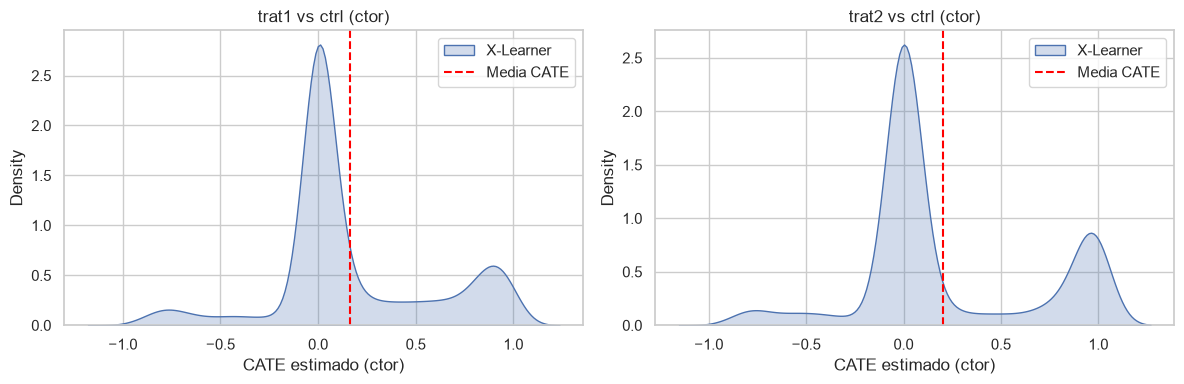

In [4]:
cate_all = pd.concat([cate_trat1.to_frame(), cate_trat2.to_frame()], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label in zip(axes, cate_all['label'].unique()):
    subset = cate_all[cate_all['label'] == label]
    sns.kdeplot(subset['cate_x'], fill=True, ax=ax, label='X-Learner')
    ax.axvline(subset['cate_x'].mean(), color='red', linestyle='--', label='Media CATE')
    ax.set_title(label)
    ax.set_xlabel('CATE estimado (ctor)')
    ax.legend()
plt.tight_layout()
plt.show()

## Heterogeneidad por segmentos

In [5]:
print('Trat1 — por edad:')
display(segment_cate_summary(cate_trat1.to_frame(), 'edad', bins=[18, 35, 50, 100], labels=['18-35', '36-50', '51+']))
print('Trat2 — por uso app:')
display(segment_cate_summary(cate_trat2.to_frame(), 'uso_app'))

Trat1 — por edad:


,mean,std,count
segment,,,
18-35,0.1495,0.3773,228
36-50,0.1787,0.4131,1485
51+,0.1553,0.4102,1628


Trat2 — por uso app:


,mean,std,count
segment,,,
No app,0.1657,0.4359,1608
Usa app,0.2395,0.4802,1756


**Validación:** La media del CATE debería aproximar el ATE del notebook 02. Si hay brecha (común con RF en outcomes binarios), usar CATE para **ranking de segmentos**, no para magnitudes absolutas. Ver [`docs/GUIA_CONCEPTUAL_TECNICA.md`](../docs/GUIA_CONCEPTUAL_TECNICA.md) §4.5.

In [6]:
validate_cate_vs_ate(df, 'trat2', 'ctor', cate_trat2).round(4)

ATE manual trat2 vs ctrl (ctor): 0.4015
Media CATE X-Learner trat2: 0.2042
